# Grid Search Experiment

This notebook runs a controlled grid search for the triangle-based evolutionary algorithm.

The grid enumerates every setup in the current `SEARCH_SPACE`, then runs 5 deterministic trials per setup. With the current grid, this is 12 setups x 5 trials = 60 expected runs.

The project minimizes fitness: lower RMSE is better. Fitness sharing is fixed on for every run as the baseline diversity-preservation mechanism. Restricted mating is part of the grid, so the experiment tests whether different mating restrictions add value when fitness sharing is already active.

The expensive execution cell is guarded by `RUN_EXPERIMENT = False`. When enabled, each trial uses notebook-configured early stopping and saves `results/grid_search/grid_search_raw_results.csv` after every completed trial so interrupted runs can resume safely.


In [103]:
%config InlineBackend.figure_format = 'retina'

import os
import sys
import json
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import load_image
from src.ga import cross_over, fitness, grid_search, mutate

cross_over = importlib.reload(cross_over)
fitness = importlib.reload(fitness)
grid_search = importlib.reload(grid_search)
mutate = importlib.reload(mutate)

## Project API Connection

Reusable grid-search mechanics live in `src/ga/grid_search.py`. This notebook keeps only the experiment configuration, execution guard, and analysis cells.


In [104]:
FITNESS_FUNCTION = fitness.compute_rmse
MUTATION_FUNCTION = mutate.random_triangle_mutation
CROSSOVER_FUNCTIONS = {
    "two_point_one_child": cross_over.two_point_crossover,
    "two_point_two_children": cross_over.two_point_crossover_two_children,
    "pmx": cross_over.pmx_crossover,
}

## Fixed Parameters

These values stay constant for every run. The alpha range uses the current fixed-alpha setting already used in the project notebooks.


In [105]:
BASE_SEED = 73
N_TRIALS = 5
FITNESS_OBJECTIVE = "minimize"
EARLY_STOPPING_PATIENCE = 50

RESULTS_DIR = project_root / "results" / "grid_search"
RAW_RESULTS_PATH = RESULTS_DIR / "grid_search_raw_results.csv"
SUMMARY_PATH = RESULTS_DIR / "grid_search_summary.csv"
BEST_CONFIG_PATH = RESULTS_DIR / "best_config.json"
IMAGE_PATH = project_root / "images" / "girl_pearl_earing.png"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FIXED_PARAMS = {
    "elitism": 5,
    "population_size": 250,
    "generations": 500,
    "triangle_alpha_range": (5, 255),
    "mutation_rate": 0.1,
    "crossover_rate": 0.9,
    "fitness_sharing": True,
    "sigma_share": 0.3,
    "n_bins": 8,
    "candidate_pool": 5,
    "evaluation_backend": "process",
    "n_jobs": 8,
    "chunksize": 5,
}

FIXED_PARAMS

{'elitism': 5,
 'population_size': 250,
 'generations': 500,
 'triangle_alpha_range': (5, 255),
 'mutation_rate': 0.1,
 'crossover_rate': 0.9,
 'fitness_sharing': True,
 'sigma_share': 0.3,
 'n_bins': 8,
 'candidate_pool': 5,
 'evaluation_backend': 'process',
 'n_jobs': 8,
 'chunksize': 5}

## Search Space

The grid search evaluates every combination in this space.


In [106]:
SEARCH_SPACE = {
    "crossover_type": [
        "two_point_one_child",
        "two_point_two_children",
        "pmx",
    ],
    "selection_type": ["tournament", "ranking"],
    "restricted_mating": ["best_partial_match", "unidirectional"],
}

SEARCH_SPACE

{'crossover_type': ['two_point_one_child', 'two_point_two_children', 'pmx'],
 'selection_type': ['tournament', 'ranking'],
 'restricted_mating': ['best_partial_match', 'unidirectional']}

## Experiment Initialization

Build the complete Cartesian-product grid of experimental configurations, initialize reproducible setup ordering and trial seeds, load the target image, and prepare the result schema used throughout the experiment pipeline.

setup_id values are assigned sequentially according to the deterministic grid order, while trial seeds follow: `seed = 73 + setup_id * 100 + trial_id`


In [107]:
# --- Generate full Cartesian-product grid of experimental configurations and load target array --- #
grid_setups = grid_search.build_grid_setups(SEARCH_SPACE)
EXPECTED_RUNS = len(grid_setups) * N_TRIALS
RESULT_COLUMNS = grid_search.RESULT_COLUMNS

# Load target array
target_array = load_image.load_target_image(IMAGE_PATH)

print(
    f"Target array: {target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]"
)
print(f"Built {len(grid_setups)} grid setups for {EXPECTED_RUNS} expected trial runs.")

Target array: (400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]
Built 12 grid setups for 60 expected trial runs.


## Run Experiment

Change `RUN_EXPERIMENT` to `True` when you are ready to launch the full sequential run. The expected total run count is computed from the grid size.


In [108]:
RUN_EXPERIMENT = True

raw_results = grid_search.load_raw_results(RAW_RESULTS_PATH)
completed = (
    set(zip(raw_results["setup_id"].astype(int), raw_results["trial_id"].astype(int)))
    if not raw_results.empty
    else set()
)
expected_pairs = {
    (int(setup_id), trial_id)
    for setup_id in grid_setups["setup_id"]
    for trial_id in range(1, N_TRIALS + 1)
}

if RUN_EXPERIMENT:
    for _, setup in grid_setups.iterrows():
        setup_id = int(setup["setup_id"])
        for trial_id in range(1, N_TRIALS + 1):
            pair = (setup_id, trial_id)
            if pair in completed:
                print(f"Skipping setup {setup_id}, trial {trial_id}: already saved.")
                continue

            print(
                f"Running setup {setup_id}/{len(grid_setups)}, trial {trial_id}/{N_TRIALS}..."
            )
            result = grid_search.run_one_trial(
                setup=setup,
                trial_id=trial_id,
                target_array=target_array,
                fixed_params=FIXED_PARAMS,
                base_seed=BASE_SEED,
                fitness_function=FITNESS_FUNCTION,
                mutation_function=MUTATION_FUNCTION,
                crossover_functions=CROSSOVER_FUNCTIONS,
                early_stopping_patience=EARLY_STOPPING_PATIENCE,
            )
            raw_results = pd.concat(
                [raw_results, pd.DataFrame([result])], ignore_index=True
            )
            grid_search.save_raw_results(raw_results, RAW_RESULTS_PATH)
            completed.add(pair)

            print(
                f"Saved setup {setup_id}, trial {trial_id}: "
                f"fitness={result['final_best_fitness']:.6f}, "
                f"generations={result['generations_run']}, "
                f"stopped_early={result['stopped_early']}, "
                f"runtime={result['runtime_seconds']:.1f}s"
            )
else:
    print("RUN_EXPERIMENT is False. Set it to True to run or resume the experiment.")

completed_pairs = expected_pairs & completed
print(f"Completed {len(completed_pairs)} / {EXPECTED_RUNS} expected runs.")

if not raw_results.empty:
    display(raw_results.sort_values(["setup_id", "trial_id"]).tail())

Skipping setup 1, trial 1: already saved.
Skipping setup 1, trial 2: already saved.
Skipping setup 1, trial 3: already saved.
Skipping setup 1, trial 4: already saved.
Skipping setup 1, trial 5: already saved.
Skipping setup 2, trial 1: already saved.
Skipping setup 2, trial 2: already saved.
Skipping setup 2, trial 3: already saved.
Skipping setup 2, trial 4: already saved.
Skipping setup 2, trial 5: already saved.
Skipping setup 3, trial 1: already saved.
Skipping setup 3, trial 2: already saved.
Skipping setup 3, trial 3: already saved.
Skipping setup 3, trial 4: already saved.
Skipping setup 3, trial 5: already saved.
Skipping setup 4, trial 1: already saved.
Skipping setup 4, trial 2: already saved.
Skipping setup 4, trial 3: already saved.
Skipping setup 4, trial 4: already saved.
Skipping setup 4, trial 5: already saved.
Skipping setup 5, trial 1: already saved.
Skipping setup 5, trial 2: already saved.
Skipping setup 5, trial 3: already saved.
Skipping setup 5, trial 4: already

,setup_id,trial_id,seed,mutation_rate,crossover_rate,crossover_type,selection_type,restricted_mating,evaluation_backend,n_jobs,chunksize,final_best_fitness,best_generation,generations_run,stopped_early,runtime_seconds
55,12,1,1274,0.1,0.9,pmx,ranking,unidirectional,process,8,5,0.140118,494,500,False,517.130385
56,12,2,1275,0.1,0.9,pmx,ranking,unidirectional,process,8,5,0.151876,497,500,False,538.698238
57,12,3,1276,0.1,0.9,pmx,ranking,unidirectional,process,8,5,0.146870,494,500,False,528.289694
58,12,4,1277,0.1,0.9,pmx,ranking,unidirectional,process,8,5,0.158926,390,440,True,482.420446
59,12,5,1278,0.1,0.9,pmx,ranking,unidirectional,process,8,5,0.140529,492,500,False,553.393905


## Aggregate Results

The summary is sorted for the project's objective direction. Because RMSE fitness is minimized, lower mean final fitness is better.


In [109]:
raw_results = grid_search.load_raw_results(RAW_RESULTS_PATH)

if raw_results.empty:
    summary = pd.DataFrame()
    print(
        "No grid search results found yet. Set RUN_EXPERIMENT = True and run the experiment cell."
    )
else:
    summary = grid_search.build_summary(raw_results)
    summary.to_csv(SUMMARY_PATH, index=False)
    print(f"Saved summary to {SUMMARY_PATH}")
    display(summary.head(10))

Saved summary to /Users/alexandre/Documents/CIFO_project/results/grid_search/grid_search_summary.csv


,setup_id,mutation_rate,crossover_rate,crossover_type,selection_type,restricted_mating,evaluation_backend,n_jobs,chunksize,mean_final_best_fitness,std_final_best_fitness,min_final_best_fitness,max_final_best_fitness,mean_generations_run,stopped_early_trials,mean_runtime_seconds,completed_trials
0,10,0.1,0.9,pmx,tournament,unidirectional,process,8,5,0.143508,0.002425,0.139690,0.146189,500.0,0,660.954447,5
1,9,0.1,0.9,pmx,tournament,best_partial_match,process,8,5,0.143532,0.002616,0.139773,0.147012,465.4,2,447.723717,5
2,11,0.1,0.9,pmx,ranking,best_partial_match,process,8,5,0.143611,0.002159,0.140345,0.145909,490.4,1,483.339952,5
3,12,0.1,0.9,pmx,ranking,unidirectional,process,8,5,0.147664,0.007954,0.140118,0.158926,488.0,1,523.986534,5
4,8,0.1,0.9,two_point_two_children,ranking,unidirectional,process,8,5,0.183243,0.010367,0.170457,0.195753,358.4,3,397.468979,5
5,4,0.1,0.9,two_point_one_child,ranking,unidirectional,process,8,5,0.187493,0.005840,0.179143,0.192814,349.6,4,343.521670,5
6,6,0.1,0.9,two_point_two_children,tournament,unidirectional,process,8,5,0.190746,0.003398,0.187479,0.195276,250.6,5,235.097779,5
7,2,0.1,0.9,two_point_one_child,tournament,unidirectional,process,8,5,0.193933,0.007143,0.186251,0.204850,199.0,5,197.718211,5
8,3,0.1,0.9,two_point_one_child,ranking,best_partial_match,process,8,5,0.211935,0.008776,0.196415,0.217704,261.8,4,289.311488,5
9,5,0.1,0.9,two_point_two_children,tournament,best_partial_match,process,8,5,0.217742,0.005656,0.212320,0.224651,142.8,5,142.441354,5


In [113]:
best_params = summary.sort_values("mean_final_best_fitness", ascending=True).iloc[0]

print(
    "Best paramenters:\n",
    best_params[
        [
            "crossover_type",
            "selection_type",
            "restricted_mating",
        ]
    ],
)

Best paramenters:
 crossover_type                  pmx
selection_type           tournament
restricted_mating    unidirectional
Name: 0, dtype: object


In [111]:
best_params_dict = best_params.to_dict()
best_setup_id = int(best_params_dict["setup_id"])
best_setup_trials = raw_results[
    raw_results["setup_id"].astype(int) == best_setup_id
].sort_values("final_best_fitness", ascending=True)
selected_trial = best_setup_trials.iloc[0]

constructor_kwargs = {
    "population_size": int(FIXED_PARAMS["population_size"]),
    "generations": int(FIXED_PARAMS["generations"]),
    "elitism": int(FIXED_PARAMS["elitism"]),
    "selection_type": str(best_params_dict["selection_type"]),
    "triangle_alpha_range": list(FIXED_PARAMS["triangle_alpha_range"]),
    "mutation_rate": float(FIXED_PARAMS["mutation_rate"]),
    "crossover_rate": float(FIXED_PARAMS["crossover_rate"]),
    "sigma_share": float(FIXED_PARAMS["sigma_share"]),
    "n_bins": int(FIXED_PARAMS["n_bins"]),
    "candidate_pool": int(FIXED_PARAMS["candidate_pool"]),
    "mating_type": str(best_params_dict["restricted_mating"]),
    "evaluation_backend": str(FIXED_PARAMS["evaluation_backend"]),
    "n_jobs": int(FIXED_PARAMS["n_jobs"]),
    "chunksize": int(FIXED_PARAMS["chunksize"]),
}

final_config = {
    "schema_version": 1,
    "ga_class": "FitnessSharingRestrictedMatingGA",
    "constructor_kwargs": constructor_kwargs,
    "operators": {
        "fitness_function": FITNESS_FUNCTION.__name__,
        "mutation_function": MUTATION_FUNCTION.__name__,
        "crossover_function": CROSSOVER_FUNCTIONS[
            str(best_params_dict["crossover_type"])
        ].__name__,
    },
    "run": {
        "base_seed": int(BASE_SEED),
        "selected_seed": int(selected_trial["seed"]),
        "selected_trial_id": int(selected_trial["trial_id"]),
        "early_stopping_patience": int(EARLY_STOPPING_PATIENCE),
        "n_trials": int(N_TRIALS),
        "objective": FITNESS_OBJECTIVE,
    },
    "selection_result": {
        "setup_id": best_setup_id,
        "mean_final_best_fitness": float(best_params_dict["mean_final_best_fitness"]),
        "std_final_best_fitness": float(best_params_dict["std_final_best_fitness"]),
        "min_final_best_fitness": float(best_params_dict["min_final_best_fitness"]),
        "max_final_best_fitness": float(best_params_dict["max_final_best_fitness"]),
        "mean_generations_run": float(best_params_dict["mean_generations_run"]),
        "stopped_early_trials": int(best_params_dict["stopped_early_trials"]),
        "mean_runtime_seconds": float(best_params_dict["mean_runtime_seconds"]),
        "completed_trials": int(best_params_dict["completed_trials"]),
    },
}

BEST_CONFIG_PATH.write_text(json.dumps(final_config, indent=4))
print(
    f"Saved best config to {BEST_CONFIG_PATH} "
    f"(setup={best_setup_id}, trial={final_config['run']['selected_trial_id']}, "
    f"seed={final_config['run']['selected_seed']})"
)

Saved best config to /Users/alexandre/Documents/CIFO_project/results/grid_search/best_config.json (setup=10, trial=3, seed=1076)


## Plots

These plots are conditional: they render only after raw results exist.


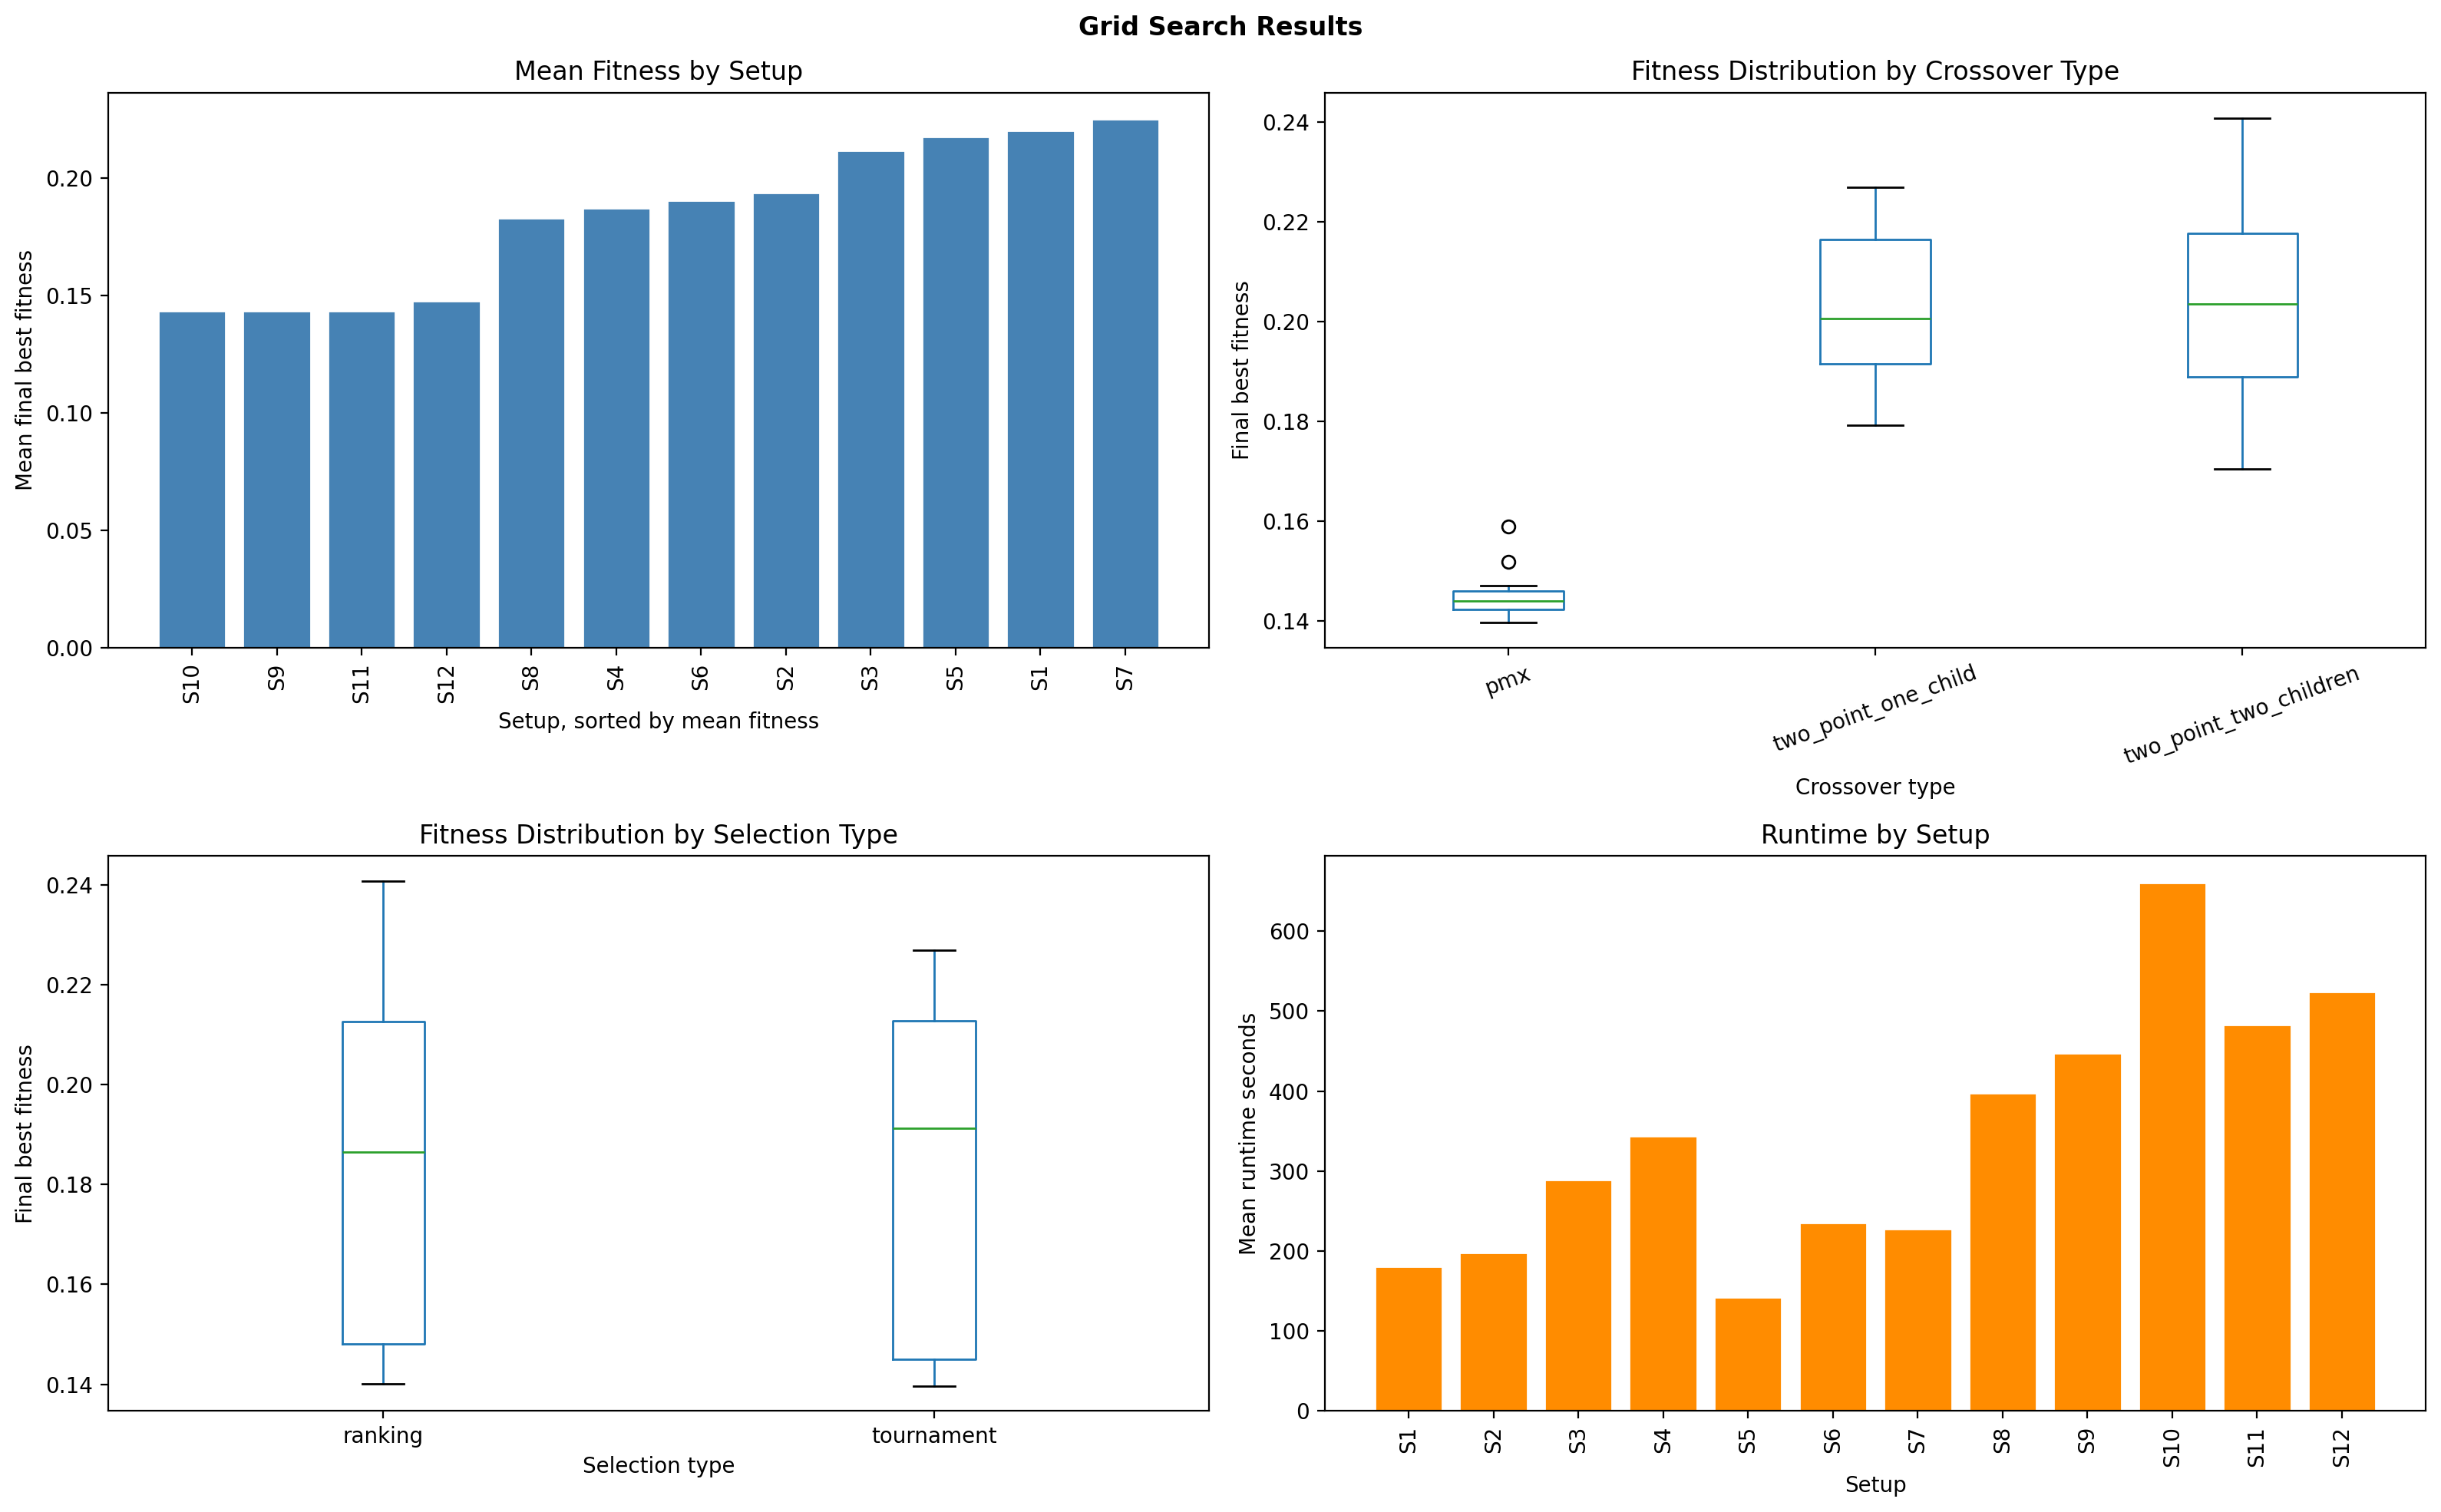

In [112]:
raw_results = grid_search.load_raw_results(RAW_RESULTS_PATH)

if raw_results.empty:
    print(
        "No grid search results found yet. Set RUN_EXPERIMENT = True and run the experiment cell."
    )
else:
    summary = grid_search.build_summary(raw_results)
    plot_summary = summary.sort_values("mean_final_best_fitness", ascending=True).copy()
    plot_summary["setup_label"] = "S" + plot_summary["setup_id"].astype(str)

    runtime_summary = summary.sort_values("setup_id", ascending=True).copy()
    runtime_summary["setup_label"] = "S" + runtime_summary["setup_id"].astype(str)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Grid Search Results", fontweight="bold")

    axes[0, 0].bar(
        plot_summary["setup_label"],
        plot_summary["mean_final_best_fitness"],
        color="steelblue",
        edgecolor="white",
    )
    axes[0, 0].set_title("Mean Fitness by Setup")
    axes[0, 0].set_xlabel("Setup, sorted by mean fitness")
    axes[0, 0].set_ylabel("Mean final best fitness")
    axes[0, 0].tick_params(axis="x", rotation=90)

    raw_results.boxplot(
        column="final_best_fitness",
        by="crossover_type",
        ax=axes[0, 1],
        grid=False,
        rot=20,
    )
    axes[0, 1].set_title("Fitness Distribution by Crossover Type")
    axes[0, 1].set_xlabel("Crossover type")
    axes[0, 1].set_ylabel("Final best fitness")

    raw_results.boxplot(
        column="final_best_fitness",
        by="selection_type",
        ax=axes[1, 0],
        grid=False,
    )
    axes[1, 0].set_title("Fitness Distribution by Selection Type")
    axes[1, 0].set_xlabel("Selection type")
    axes[1, 0].set_ylabel("Final best fitness")

    axes[1, 1].bar(
        runtime_summary["setup_label"],
        runtime_summary["mean_runtime_seconds"],
        color="darkorange",
        edgecolor="white",
    )
    axes[1, 1].set_title("Runtime by Setup")
    axes[1, 1].set_xlabel("Setup")
    axes[1, 1].set_ylabel("Mean runtime seconds")
    axes[1, 1].tick_params(axis="x", rotation=90)

    plt.suptitle("Grid Search Results", fontweight="bold")
    plt.tight_layout()
    plt.show()